In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import numpy as np
from tools.vae_models import VAE  # Import the unified VAE model

# Load the digits dataset
digits = load_digits()
X, y = digits.data / 16.0, digits.target  # Normalize the data
X = X.reshape(-1, 1, 8, 8)  # Reshape to (n_samples, 1, 8, 8)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X, y)
# Split the dataset into training, validation, and test sets
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_batch_size = 72
val_batch_size = 72
test_batch_size = 72

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# print the size of the input, the number for batches in each loader and the range of values in the input
print(f'Input size: {X.size()}')
print(f'Number of training batches: {len(train_loader)}')
print(f'Number of validation batches: {len(val_loader)}')
print(f'Number of test batches: {len(test_loader)}')
print(f'Input value range: {X.min().item()} to {X.max().item()}')


Input size: torch.Size([1797, 1, 8, 8])
Number of training batches: 18
Number of validation batches: 3
Number of test batches: 6
Input value range: 0.0 to 1.0


In [13]:
# def vae_loss(x, x_recon, z_mean, z_logvar):
#     recon_loss = F.mse_loss(x_recon, x, reduction='sum')
#     kl_div = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
#     return recon_loss + kl_div

def vae_loss(x, x_recon, z_mean, z_logvar, beta=1.0):
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')  # Reconstruction loss
    kl_div = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())  # KL divergence
    return recon_loss + beta * kl_div, recon_loss, beta * kl_div  # Weighted sum of reconstruction and KL divergence

# def vae_loss(x, x_recon, z_mean, z_logvar, beta=1.0):
#     # MSE for continuous reconstruction, normalized by the number of elements
#     mse_loss = nn.MSELoss(reduction='sum')
#     mse = mse_loss(x_recon, x) / x.numel()
# 
#     # KL Divergence, normalized by the batch size
#     kl_divergence = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
#     kl_divergence /= x.size(0)
# 
#     return mse + beta * kl_divergence, mse, kl_divergence

# KL is usually much smaller so we scale it up by a factor of beta
# def vae_loss(x, x_recon, z_mean, z_logvar, beta=1.0):
#     # MSE for continuous reconstruction, normalized by the number of elements
#     mse_loss = nn.MSELoss(reduction='sum')
#     mse = mse_loss(x_recon, x) / x.numel()
# 
#     # KL Divergence, normalized by the batch size
#     kl_divergence = -0.5 * torch.sum(1 + z_logvar - z_mean.pow(2) - z_logvar.exp())
#     kl_divergence /= x.size(0)
# 
#     # Scale KL divergence with beta
#     kl_divergence *= beta
# 
#     return mse + kl_divergence, mse, kl_divergence



Training Progress:  37%|███▋      | 3682/10000 [43:28<1:14:36,  1.41epoch/s, Train Loss=1.7912, Recon Loss=1.7808, KL Loss=0.0104, Status=↓, Last Val Loss=inf]


Early stopping triggered
Training finished.


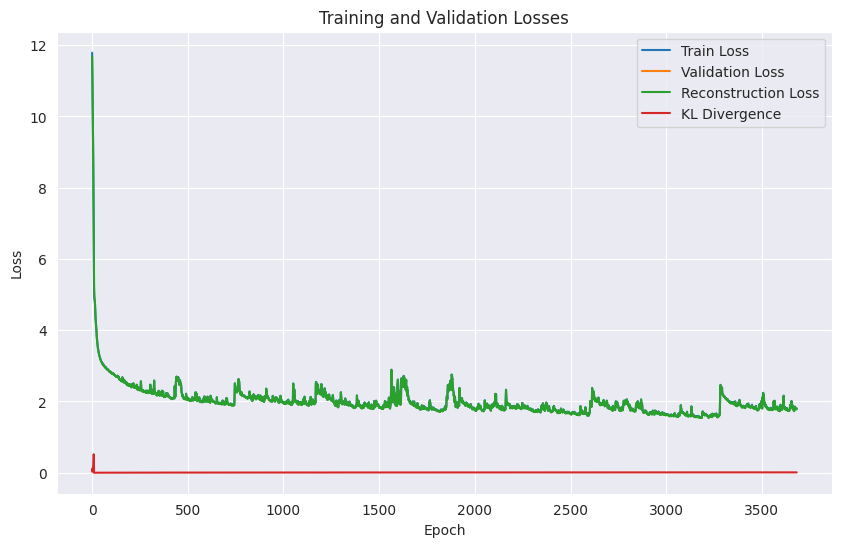

In [7]:
import torch
import tools
from tqdm import tqdm
import matplotlib.pyplot as plt
from tools.vae_models import VAE, VAEModelTypes
from tools.vae_training import train_vae

# Reload vae_models
import importlib

importlib.reload(tools.vae_models)
importlib.reload(tools.vae_training)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 8 * 8  # Digits images are 8x8 pixels
hidden_dim = 64
latent_dim = 2

# Example: Using Baseline 2D VAE by string identifier
# vae = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, model_type="baseline").to(device)

# Try the tranformer 2D VAE
vae = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, model_type='2d_transformer').to(device)

# Training parameters
num_epochs = 10000
learning_rate = 1e-4
beta_start = 1.0
beta_end = 0.0001
patience = 500  # Number of epochs to wait for improvement
min_delta = 0.001  # Minimum change to qualify as an improvement
scheduler_step_size = 100
scheduler_gamma = 1.0

# Call the train_vae function
train_losses, val_losses, recon_losses, kl_losses = train_vae(
    vae=vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    beta_start=beta_start,
    beta_end=beta_end,
    patience=patience,
    min_delta=min_delta,
    kl_anneal_epochs=10,
    val_interval=num_epochs,
    scheduler_step_size=scheduler_step_size,
    scheduler_gamma=scheduler_gamma
)

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Losses')
plt.show()


In [2]:
import torch
import tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from tools.vae_models import VAE, VAEModelTypes
from tools.vae_training import train_vae, parameter_search
import itertools
# Reload vae_models
import importlib

importlib.reload(tools.vae_models)
importlib.reload(tools.vae_training)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the parameter grid
param_grid = {
    'input_dim': [8*8],
    'hidden_dim': [64, 128],
    'latent_dim': [2],
    'learning_rate': [1e-3, 1e-4],
    'beta_tuple': [(0.001, 1), (0.1, 1), (10, 1), (100, 1), (10, 0.1), (1, 0.1), (1, 0.001), (10, 0.001)],
    'num_epochs': [2000],  # Set lower for testing
    'patience': [200],
    'min_delta': [0.001],
    'kl_anneal_epochs': [50],
    'val_interval': [10],
    'scheduler_step_size': [50, 100],
    'scheduler_gamma': [0.9, 1.0]
}


# Create list of all parameter combinations
param_combinations = [dict(zip(param_grid.keys(), values)) for values in itertools.product(*param_grid.values())]

# Run the parameter search
output_folder = "/gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/parameter_search_results_transformer"
parameter_search(train_loader, val_loader, test_loader, device, param_combinations, output_folder, model_type='2d_transformer')


Using encoder: TransformerEncoder2D, decoder: TransformerDecoder2D
Training with parameters: hidden_dim=64, learning_rate=0.001, beta_start=0.001, beta_end=1, scheduler_gamma=0.9, scheduler_step_size=50, kl_anneal_epochs=50, patience=200, min_delta=0.001


Training Progress:  20%|██        | 408/2000 [04:47<18:40,  1.42epoch/s, Train Loss=4.6967, Recon Loss=4.6966, KL Loss=0.0000, Status=↓, Last Val Loss=4.5970]


Early stopping triggered
Training finished.
Using encoder: TransformerEncoder2D, decoder: TransformerDecoder2D
Training with parameters: hidden_dim=64, learning_rate=0.001, beta_start=0.001, beta_end=1, scheduler_gamma=1.0, scheduler_step_size=50, kl_anneal_epochs=50, patience=200, min_delta=0.001


Training Progress:  15%|█▌        | 309/2000 [03:30<19:13,  1.47epoch/s, Train Loss=4.7044, Recon Loss=4.7043, KL Loss=0.0000, Status=↓, Last Val Loss=4.6081]


Early stopping triggered
Training finished.
Using encoder: TransformerEncoder2D, decoder: TransformerDecoder2D
Training with parameters: hidden_dim=64, learning_rate=0.001, beta_start=0.001, beta_end=1, scheduler_gamma=0.9, scheduler_step_size=100, kl_anneal_epochs=50, patience=200, min_delta=0.001


...

Training finished.
Using encoder: TransformerEncoder2D, decoder: TransformerDecoder2D
Training with parameters: hidden_dim=128, learning_rate=0.0001, beta_start=10, beta_end=0.001, scheduler_gamma=0.9, scheduler_step_size=100, kl_anneal_epochs=50, patience=200, min_delta=0.001


Training Progress:  44%|████▍     | 879/2000 [10:08<12:56,  1.44epoch/s, Train Loss=2.0392, Recon Loss=2.0158, KL Loss=0.0234, Status=↓, Last Val Loss=2.0519]


Early stopping triggered
Training finished.
Using encoder: TransformerEncoder2D, decoder: TransformerDecoder2D
Training with parameters: hidden_dim=128, learning_rate=0.0001, beta_start=10, beta_end=0.001, scheduler_gamma=1.0, scheduler_step_size=100, kl_anneal_epochs=50, patience=200, min_delta=0.001


Training Progress:  40%|████      | 804/2000 [09:40<14:23,  1.39epoch/s, Train Loss=2.0246, Recon Loss=2.0014, KL Loss=0.0232, Status=↓, Last Val Loss=2.2027]


Early stopping triggered
Training finished.


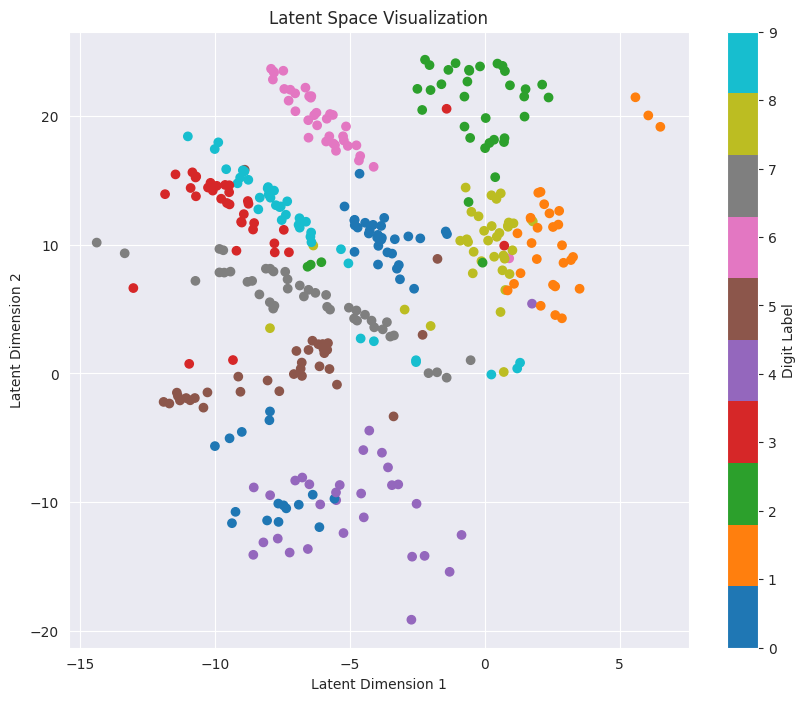

In [8]:
# Plot the latent space
vae.eval()
z_means = []
labels = []
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        z_mean, z_logvar = vae.encoder(data)
        z_means.append(z_mean)
        labels.append(label)

z_means = torch.cat(z_means).cpu().numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(10, 8))
plt.scatter(z_means[:, 0], z_means[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='Digit Label')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Visualization')
plt.show()


In [ ]:
import random

def generate_saliency_map(vae, data_point):
    vae.eval()
    data_point.requires_grad = True
    _, z_mean, _ = vae(data_point)
    loss = z_mean.sum()  # Sum the latent variables to create a scalar
    loss.backward()
    saliency = data_point.grad.abs().detach()
    return saliency

# Select a random image from the test set
random_index = random.randint(0, len(test_dataset) - 1)
data_point, label = test_dataset[random_index]
data_point, label = data_point.unsqueeze(0).to(device), label

# Generate saliency map
saliency_map = generate_saliency_map(vae, data_point)

# Print the index of the chosen image
print(f'Randomly chosen image index: {random_index}')

# Plot the saliency map
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f'Original Image (Label: {label.item()})')
plt.imshow(data_point.cpu().detach().squeeze(), cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Saliency Map')
plt.imshow(saliency_map.cpu().detach().squeeze(), cmap='hot')
plt.colorbar()
plt.show()


In [26]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import string

def generate_saliency_map(vae, data_point):
    vae.eval()
    data_point.requires_grad = True
    _, z_mean, _ = vae(data_point)
    loss = z_mean.sum()  # Sum the latent variables to create a scalar
    loss.backward()
    saliency = data_point.grad.abs().detach()
    return saliency

def generate_random_images(vae, num_images=10):
    vae.eval()
    
    if hasattr(vae.encoder, 'fc_mu'):  # Check if the encoder has the 'fc_mu' attribute
        latent_dim = vae.encoder.fc_mu.out_features  # Get the latent dimension size for Transformer-based VAE
    else:
        latent_dim = vae.encoder.fc2_mean.out_features  # Get the latent dimension size for Basic VAE
        
    print(f'Latent dimension size: {latent_dim}')
    
    random_latent_vectors = torch.randn(num_images, latent_dim).to(device)  # Sample random points in the latent space
    
    with torch.no_grad():
        generated_images = vae.decoder(random_latent_vectors).cpu()
    
    return random_latent_vectors.cpu().numpy(), generated_images


def generate_random_images_within_bounds(vae, num_images=10, z_means=None):
    vae.eval()
    
    if hasattr(vae.encoder, 'fc_mu'):  # Check if the encoder has the 'fc_mu' attribute
        latent_dim = vae.encoder.fc_mu.out_features  # Get the latent dimension size for Transformer-based VAE
    else:
        latent_dim = vae.encoder.fc2_mean.out_features  # Get the latent dimension size for Basic VAE
    
    # Determine the min and max values for each dimension of the latent space
    min_values = np.min(z_means, axis=0)
    max_values = np.max(z_means, axis=0)
    
    # Sample random points within the latent space boundaries
    random_latent_vectors = torch.FloatTensor(num_images, latent_dim).uniform_(0, 1)
    for i in range(latent_dim):
        random_latent_vectors[:, i] = random_latent_vectors[:, i] * (max_values[i] - min_values[i]) + min_values[i]
    random_latent_vectors = random_latent_vectors.to(device)
    
    with torch.no_grad():
        generated_images = vae.decoder(random_latent_vectors).cpu()
    
    return random_latent_vectors.cpu().numpy(), generated_images



Randomly chosen image index: 282


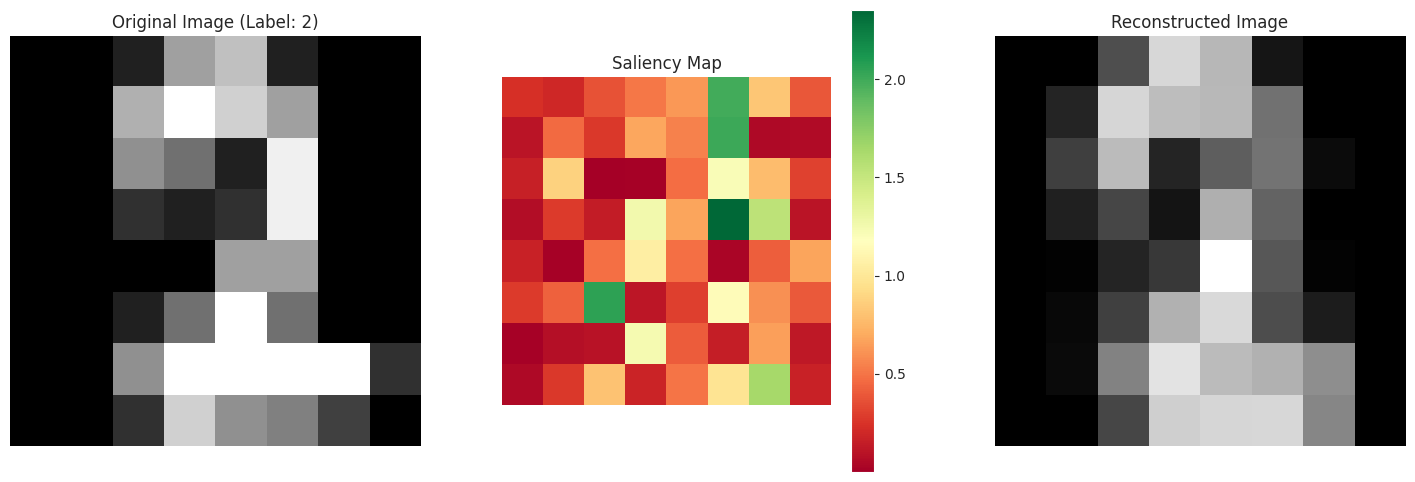

In [19]:

# Select a random image from the test set
random_index = random.randint(0, len(test_dataset) - 1)
data_point, label = test_dataset[random_index]
data_point, label = data_point.unsqueeze(0).to(device), label

# Generate saliency map
saliency_map = generate_saliency_map(vae, data_point)

# Get reconstruction
vae.eval()
with torch.no_grad():
    x_recon, z_mean, _ = vae(data_point)

# Print the index of the chosen image
print(f'Randomly chosen image index: {random_index}')

# Plot the original image, saliency map, and reconstructed image
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title(f'Original Image (Label: {label.item()})')
plt.imshow(data_point.cpu().detach().squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Saliency Map')
plt.imshow(saliency_map.cpu().detach().squeeze(), cmap='RdYlGn')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Reconstructed Image')
plt.imshow(x_recon.cpu().detach().squeeze(), cmap='gray')
plt.axis('off')

plt.show()

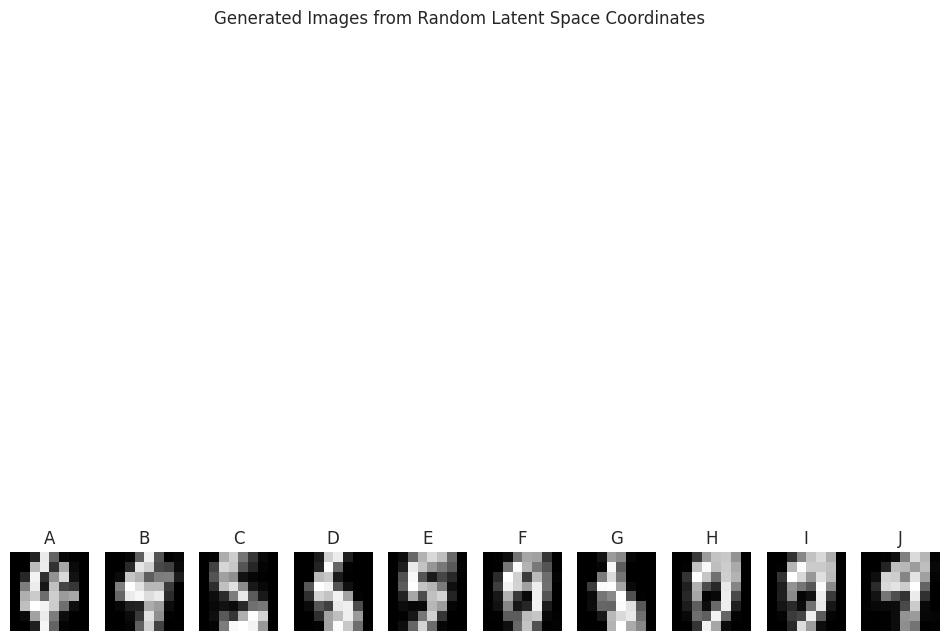

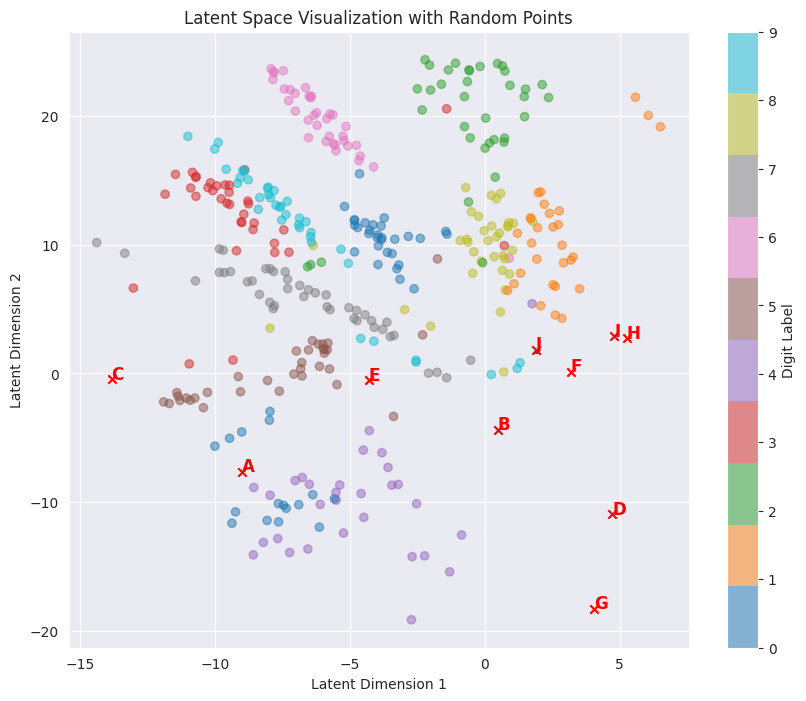

In [27]:
import string

# Generate new images
num_images = 10
random_latent_vectors, generated_images = generate_random_images_within_bounds(vae, num_images, z_means)
letters = string.ascii_uppercase[:num_images]  # Use first num_images letters

# Plot the generated images with letters
plt.figure(figsize=(12, 12))
for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.title(letters[i])
    plt.axis('off')
plt.suptitle('Generated Images from Random Latent Space Coordinates')
plt.show()

# Plot the random points in the latent space along with the original latent space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_means[:, 0], z_means[:, 1], c=labels, cmap='tab10', alpha=0.5)
for i, letter in enumerate(letters):
    plt.scatter(random_latent_vectors[i, 0], random_latent_vectors[i, 1], c='red', marker='x')
    plt.text(random_latent_vectors[i, 0], random_latent_vectors[i, 1], letter, color='red', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Digit Label')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Visualization with Random Points')
plt.show()


In [16]:
import pandas as pd

# Function to extract embeddings
def extract_embeddings(vae, data_loader, device):
    vae.eval()
    embeddings = []
    scores = []
    with torch.no_grad():
        for data, labels in data_loader:
            data = data.to(device)
            z_mean, z_logvar = vae.encoder(data)
            embeddings.append(z_mean.cpu().numpy())
            scores.append(labels.cpu().numpy())
    embeddings = np.concatenate(embeddings, axis=0)
    scores = np.concatenate(scores, axis=0)
    return embeddings, scores

# Extract embeddings for training and test datasets
train_embeddings, train_scores = extract_embeddings(vae, train_loader, device)
test_embeddings, test_scores = extract_embeddings(vae, test_loader, device)


In [17]:
# Convert embeddings and scores to data frames
train_df = pd.DataFrame({
    'embeddings': [emb.tolist() for emb in train_embeddings],
    'scores': train_scores
})

test_df = pd.DataFrame({
    'embeddings': [emb.tolist() for emb in test_embeddings],
    'scores': test_scores
})

scores - Avg Training R^2: 0.9453278081068224
scores - Avg Normalized Training MSE: 0.55%, Avg Normalized Training MAE: 3.78%, Avg MAE_max% Training: 3.78%
scores - Test R^2: 0.711819176443035
scores - Normalized Test MSE: 3.10%, Normalized Test MAE: 9.82%, Test MAE_max%: 9.82%
Model 0 saved to /gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer/scores_model_fold_0.pkl
Model 1 saved to /gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer/scores_model_fold_1.pkl
Model 2 saved to /gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer/scores_model_fold_2.pkl
Model 3 saved to /gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer/scores_model_fold_3.pkl
Model 4 saved to /gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer/scores_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:300: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


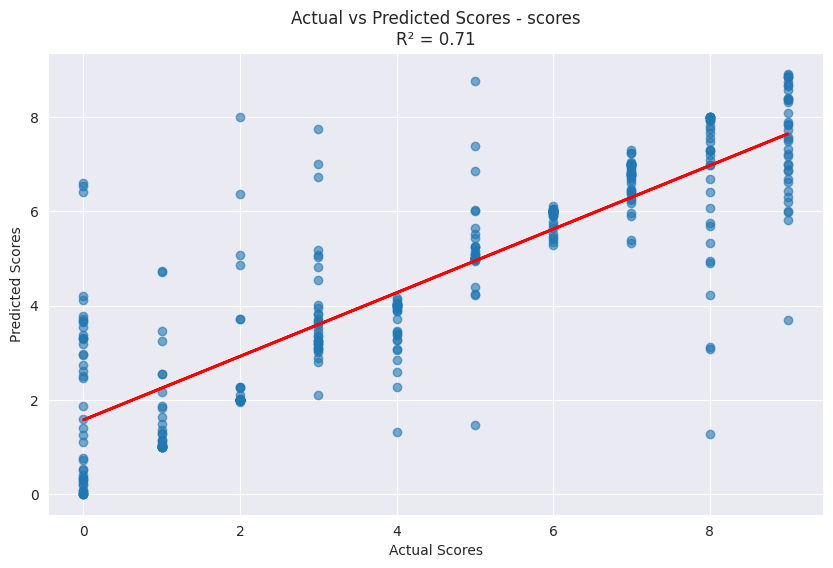

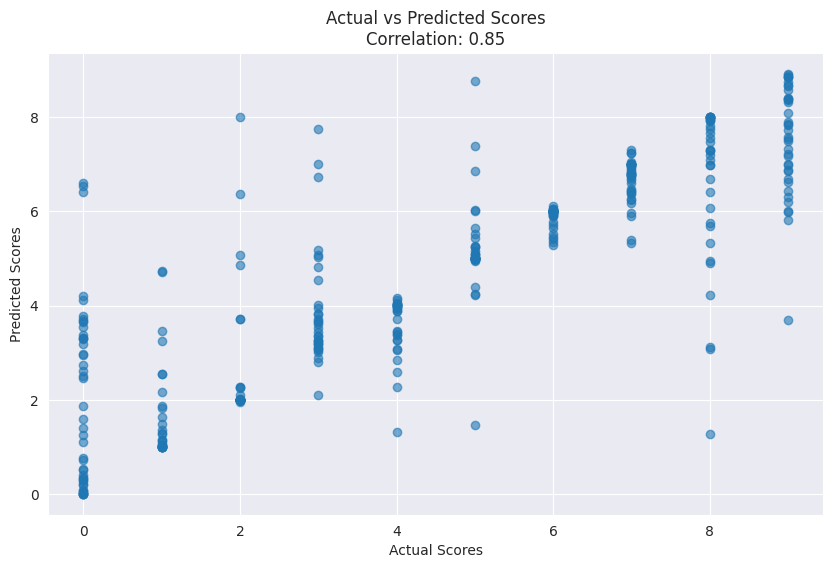

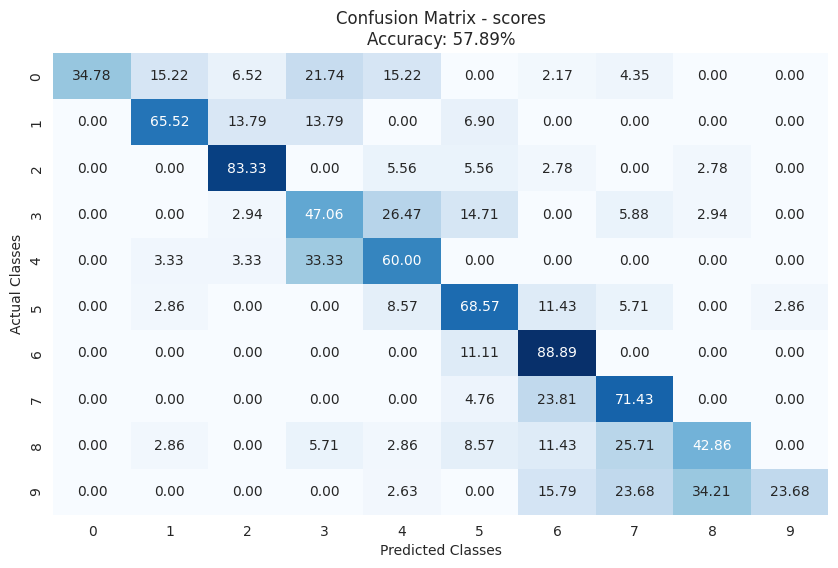

In [18]:
from tools.stats_utils import train_model

# Prepare data and call the train_model function
score_name = 'scores'
# output_folder = r'S:\GIN Dropbox\Chris Foulon\EMUSE\mnist_numbers\tests_vaes\transformer'
output_folder = "/gamma/GIN Dropbox/Chris Foulon/EMUSE/mnist_numbers/tests_vaes/transformer"

# Call the train_model function with the prepared data
train_model(train_df, test_df, score_name, output_folder, categorical=True)